# Prática 01 — Caminhos mínimos (versão didática)

Notebook simplificado com a mesma organização em partes do original: Parte 1 (a–f) para Dijkstra e Parte 2 (a–f) para a Heurística Gulosa. Foco em clareza e execução rápida.

In [ ]:
# Imports mínimos e utilitários
from typing import Dict, List, Tuple, Optional
from collections import deque
from math import inf
import heapq, random, os
import matplotlib.pyplot as plt
import networkx as nx

# Funções simples para salvar resultados e imagens

def garantir_pasta_saida(pasta: str) -> str:
    os.makedirs(pasta, exist_ok=True)
    return pasta


def salvar_tabela_txt(cabecalho: str, linhas: List[Tuple], caminho: str) -> None:
    garantir_pasta_saida(os.path.dirname(caminho))
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(cabecalho.strip() + "\n")
        for row in linhas:
            f.write("\t".join(str(x) for x in row) + "\n")
    print(f"[OK] Tabela salva em: {caminho}")


def salvar_resultado_simples(dist: Dict[int, float], parent: Dict[int, Optional[int]], caminho: str) -> None:
    garantir_pasta_saida(os.path.dirname(caminho))
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(f"n={len(dist)}\n")
        for v in sorted(dist.keys()):
            dv = dist[v]
            dist_str = f"{dv:.2f}" if dv != inf else "inf"
            parent_str = str(parent[v]) if parent[v] is not None else "None"
            f.write(f"{v}: dist={dist_str}, parent={parent_str}\n")
    print(f"[OK] Resultado salvo em: {caminho}")


def plotar_grafo_adj(adj: Dict[int, List[Tuple[int, float]]], titulo: str, caminho_img: Optional[str] = None, seed: Optional[int] = None) -> None:
    """Plota um grafo dirigido a partir de uma lista de adjacência usando NetworkX."""
    G = nx.DiGraph()
    for u, viz in adj.items():
        for v, w in viz:
            G.add_edge(u, v, weight=w)
    pos = nx.spring_layout(G, seed=seed if seed is not None else (globals().get('SEED', 42)))
    plt.figure(figsize=(7, 5))
    nx.draw_networkx_nodes(G, pos, node_color="#f0f0f0", edgecolors="#333", node_size=800)
    nx.draw_networkx_labels(G, pos, font_size=9)
    nx.draw_networkx_edges(G, pos, edge_color="#999", width=1.2, arrows=True, arrowsize=16)
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.title(titulo)
    plt.axis('off')
    if caminho_img:
        garantir_pasta_saida(os.path.dirname(caminho_img))
        plt.savefig(caminho_img, dpi=150, bbox_inches='tight')
        print(f"[OK] Imagem salva em: {caminho_img}")
    plt.show()

# Função de geração + exemplo e plotagem

def grafo_completo(n: int, wmin: float = 1.0, wmax: float = 10.0, seed: Optional[int] = None) -> Dict[int, List[Tuple[int, float]]]:
    """Gera grafo completo dirigido com pesos positivos (sem laços)."""
    if seed is not None:
        random.seed(seed)
    adj: Dict[int, List[Tuple[int, float]]] = {u: [] for u in range(n)}
    for u in range(n):
        for v in range(n):
            if u != v:
                adj[u].append((v, random.uniform(wmin, wmax)))
    return adj

---
# PARTE 1 — ALGORITMO DE DIJKSTRA
---

Nesta parte implementamos e exercitamos o Dijkstra com contagem de comparações.

In [ ]:
# Parâmetros básicos usados em (a)-(e)
N_min, N_max = 4, 100
N_exemplo = 5
SEED = 42

## (a) Gerar grafos completos com pesos positivos
- Representação: lista de adjacência {u: [(v, w), ...]}.
- Pesos estritamente positivos (w > 0).
- Usamos uma semente para reprodutibilidade.

[OK] Imagem salva em: resultados/dijkstra/img/grafo_exemplo_parte1a.png


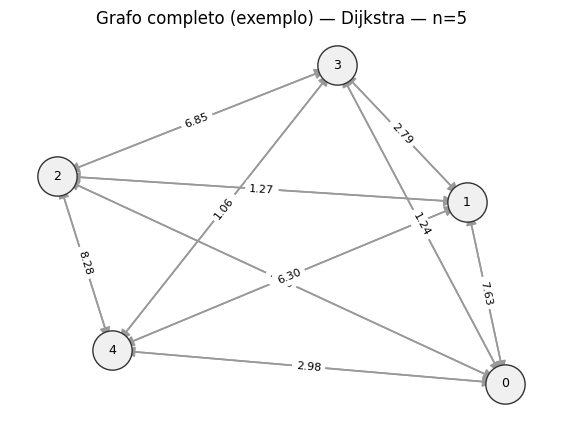

In [ ]:
# Função de geração + exemplo e plotagem

def grafo_completo(n: int, wmin: float = 1.0, wmax: float = 10.0, seed: Optional[int] = None) -> Dict[int, List[Tuple[int, float]]]:
    """Gera grafo completo dirigido com pesos positivos (sem laços)."""
    if seed is not None:
        random.seed(seed)
    adj: Dict[int, List[Tuple[int, float]]] = {u: [] for u in range(n)}
    for u in range(n):
        for v in range(n):
            if u != v:
                adj[u].append((v, random.uniform(wmin, wmax)))
    return adj

# Exemplo mínimo
G_ex = grafo_completo(N_exemplo, seed=SEED)
list(G_ex.items())[:2]  # pré-visualização

# Plotar com NetworkX e salvar
plotar_grafo_adj(G_ex, f"Grafo completo (exemplo) — Dijkstra — n={N_exemplo}",
                 "resultados/dijkstra/img/grafo_exemplo_parte1a.png", seed=SEED)

## (b) Armazenar grafos (lista de adjacência)
Geramos e guardamos grafos para n em [N_min, N_max].

In [5]:
ns = list(range(N_min, N_max + 1))
grafos = [grafo_completo(n, seed=SEED) for n in ns]
len(grafos), ns[0], ns[-1]

(7, 4, 10)

## (c) Aplicar Dijkstra (origem 0)
Implementação simples com contagem de comparações de relaxamento.

In [6]:
def dijkstra_count(adj: Dict[int, List[Tuple[int, float]]], s: int = 0):
    if not adj or s not in adj:
        raise ValueError('Grafo vazio ou origem inválida')
    for u, viz in adj.items():
        for v, w in viz:
            if w < 0:
                raise ValueError(f'Dijkstra requer pesos não negativos (aresta {u}->{v} com peso {w})')
    dist: Dict[int, float] = {u: inf for u in adj}
    parent: Dict[int, Optional[int]] = {u: None for u in adj}
    dist[s] = 0.0
    pq: List[Tuple[float, int]] = [(0.0, s)]
    comparisons = 0
    while pq:
        du, u = heapq.heappop(pq)
        if du != dist[u]:
            continue
        for v, w in adj[u]:
            comparisons += 1
            nd = du + w
            if nd < dist[v]:
                dist[v] = nd
                parent[v] = u
                heapq.heappush(pq, (nd, v))
    return dist, parent, comparisons

res_d = [dijkstra_count(g, 0) for g in grafos]
comparacoes_d = [r[2] for r in res_d]
list(zip(ns, comparacoes_d))[:3]

[(4, 12), (5, 20), (6, 30)]

## (d) Contar comparações
Exibimos (n, comparações) diretamente (sem salvar em arquivo para simplificar).

In [7]:
print('n\tcomparacoes')
for n, c in zip(ns, comparacoes_d):
    print(f'{n}\t{c}')

# Salvar também em arquivo TXT e resultados por grafo
pasta_out = garantir_pasta_saida('resultados/dijkstra')
salvar_tabela_txt('n\tcomparacoes', list(zip(ns, comparacoes_d)), f"{pasta_out}/dijkstra_comparacoes.txt")

for n, (dist, parent, comp) in zip(ns, res_d):
    salvar_resultado_simples(dist, parent, f"{pasta_out}/resultado_dijkstra_n{n}.txt")

n	comparacoes
4	12
5	20
6	30
7	42
8	56
9	72
10	90
[OK] Tabela salva em: resultados/dijkstra/dijkstra_comparacoes.txt
[OK] Resultado salvo em: resultados/dijkstra/resultado_dijkstra_n4.txt
[OK] Resultado salvo em: resultados/dijkstra/resultado_dijkstra_n5.txt
[OK] Resultado salvo em: resultados/dijkstra/resultado_dijkstra_n6.txt
[OK] Resultado salvo em: resultados/dijkstra/resultado_dijkstra_n7.txt
[OK] Resultado salvo em: resultados/dijkstra/resultado_dijkstra_n8.txt
[OK] Resultado salvo em: resultados/dijkstra/resultado_dijkstra_n9.txt
[OK] Resultado salvo em: resultados/dijkstra/resultado_dijkstra_n10.txt


## (e) Plotar n vs comparações
Usamos Matplotlib para um gráfico simples.

[OK] Gráfico salvo em: resultados/dijkstra/img/dijkstra_comparacoes.png


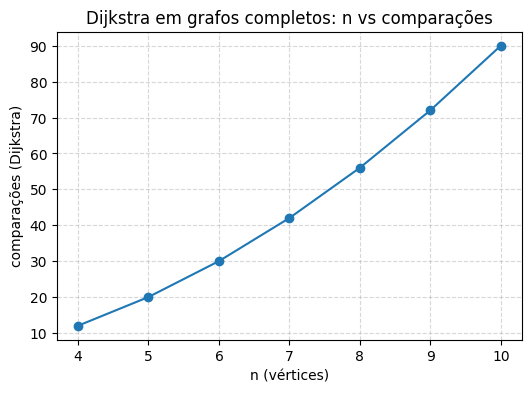

In [8]:
plt.figure(figsize=(6,4))
plt.plot(ns, comparacoes_d, marker='o')
plt.xlabel('n (vértices)')
plt.ylabel('comparações (Dijkstra)')
plt.title('Dijkstra em grafos completos: n vs comparações')
plt.grid(True, linestyle='--', alpha=0.5)

# Salvar imagem
pasta_img = garantir_pasta_saida('resultados/dijkstra/img')
plt.savefig(f"{pasta_img}/dijkstra_comparacoes.png", dpi=150, bbox_inches='tight')
print(f"[OK] Gráfico salvo em: {pasta_img}/dijkstra_comparacoes.png")
plt.show()

## (f) Instâncias grandes (10k e 1M) — opcional
Para evitar travamentos acidentais, só tentamos rodar se os arquivos existirem.
Atualize os caminhos conforme seu ambiente.

In [9]:
caminho_10k = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\10000.txt'
caminho_1m  = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\largeEWD - contains one million vertices and 15172126 edges.txt'

def carregar_ewd_cabecalho(caminho: str) -> Dict[int, List[Tuple[int, float]]]:
    with open(caminho, 'r', encoding='utf-8') as f:
        V = int(f.readline().strip())
        E = int(f.readline().strip())
        adj = {i: [] for i in range(V)}
        for _ in range(E):
            linha = f.readline()
            if not linha:
                break
            u, v, w = linha.split()[:3]
            adj[int(u)].append((int(v), float(w)))
    return adj

def roda_grande(caminho: str, nome: str):
    if not os.path.exists(caminho):
        print(f'[INFO] Arquivo não encontrado: {nome}')
        return None
    print(f'Carregando {nome}...')
    adj = carregar_ewd_cabecalho(caminho)
    print(f'Rodando Dijkstra (origem=0) ...')
    dist, parent, comp = dijkstra_count(adj, 0)
    print(f'Comparações: {comp:,} — Vértices: {len(dist):,}')
    return comp

_ = roda_grande(caminho_10k, 'Instância 10k')  # roda se existir
# _ = roda_grande(caminho_1m, 'Instância 1M')   # descomente por sua conta e risco

Carregando Instância 10k...
Rodando Dijkstra (origem=0) ...
Comparações: 123,462 — Vértices: 10,000
Comparações: 123,462 — Vértices: 10,000


---
# PARTE 2 — HEURÍSTICA GULOSA
---

Heurística de vizinho mais próximo (não garante ótimo). Organização idêntica (a–f).

## (a) Gerar grafos completos
Reutilizamos a função `grafo_completo`.

[OK] Imagem salva em: resultados/gulosa/img/grafo_exemplo_parte2a.png


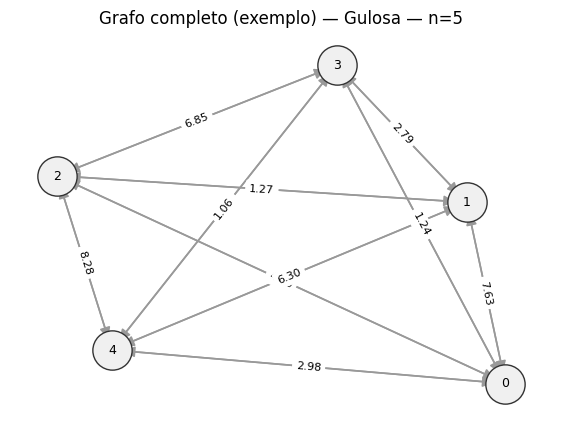

In [25]:
# Parte 2(a): gerar grafo reutilizando grafo_completo e plotar
Gg_ex = grafo_completo(N_exemplo, seed=SEED)
list(Gg_ex.items())[:2]

plotar_grafo_adj(Gg_ex, f"Grafo completo (exemplo) — Gulosa — n={N_exemplo}",
                 "resultados/gulosa/img/grafo_exemplo_parte2a.png", seed=SEED)

## (b) Armazenar grafos
Geramos e guardamos grafos para n em [N_min, N_max] (podemos reutilizar os de cima).

In [13]:
ns_g = ns  # reutiliza
grafos_g = grafos  # reutiliza
len(grafos_g), ns_g[0], ns_g[-1]

(7, 4, 10)

## (c) Aplicar heurística (origem 0)
Versão simples usando deque; marca visita no momento da melhoria.

In [14]:
def gulosa_vizinho_proximo(adj: Dict[int, List[Tuple[int, float]]], s: int = 0):
    if s not in adj:
        raise ValueError('Origem inválida')
    dist: Dict[int, float] = {u: inf for u in adj}
    parent: Dict[int, Optional[int]] = {u: None for u in adj}
    dist[s] = 0.0
    visited = {s}
    q = deque([s])
    comparisons = 0
    while q:
        u = q.popleft()
        melhor, melhor_custo = None, inf
        for v, w in adj[u]:
            comparisons += 1
            if v in visited:
                continue
            custo = dist[u] + w
            if custo < dist[v] and custo < melhor_custo:
                melhor_custo, melhor = custo, v
        if melhor is not None:
            dist[melhor] = melhor_custo
            parent[melhor] = u
            visited.add(melhor)
            q.append(melhor)
    return dist, parent, comparisons

res_g = [gulosa_vizinho_proximo(g, 0) for g in grafos_g]
comparacoes_g = [r[2] for r in res_g]
list(zip(ns_g, comparacoes_g))[:3]

[(4, 12), (5, 20), (6, 30)]

## (d) Contar comparações
Exibimos (n, comparações) diretamente.

In [15]:
print('n\tcomparacoes (gulosa)')
for n, c in zip(ns_g, comparacoes_g):
    print(f'{n}\t{c}')

# Salvar também em arquivo TXT e resultados por grafo
pasta_out = garantir_pasta_saida('resultados/gulosa')
salvar_tabela_txt('n\tcomparacoes', list(zip(ns_g, comparacoes_g)), f"{pasta_out}/gulosa_comparacoes.txt")

for n, (dist, parent, comp) in zip(ns_g, res_g):
    salvar_resultado_simples(dist, parent, f"{pasta_out}/resultado_gulosa_n{n}.txt")

n	comparacoes (gulosa)
4	12
5	20
6	30
7	42
8	56
9	72
10	90
[OK] Tabela salva em: resultados/gulosa/gulosa_comparacoes.txt
[OK] Resultado salvo em: resultados/gulosa/resultado_gulosa_n4.txt
[OK] Resultado salvo em: resultados/gulosa/resultado_gulosa_n5.txt
[OK] Resultado salvo em: resultados/gulosa/resultado_gulosa_n6.txt
[OK] Resultado salvo em: resultados/gulosa/resultado_gulosa_n7.txt
[OK] Resultado salvo em: resultados/gulosa/resultado_gulosa_n8.txt
[OK] Resultado salvo em: resultados/gulosa/resultado_gulosa_n9.txt
[OK] Resultado salvo em: resultados/gulosa/resultado_gulosa_n10.txt


## (e) Plotar n vs comparações (gulosa)
Gráfico simples.

[OK] Gráfico salvo em: resultados/gulosa/img/gulosa_comparacoes.png


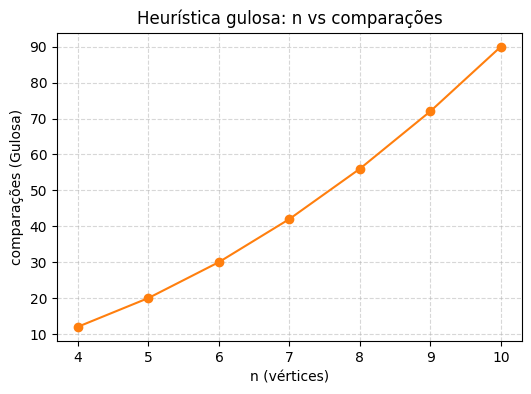

In [16]:
plt.figure(figsize=(6,4))
plt.plot(ns_g, comparacoes_g, marker='o', color='tab:orange')
plt.xlabel('n (vértices)')
plt.ylabel('comparações (Gulosa)')
plt.title('Heurística gulosa: n vs comparações')
plt.grid(True, linestyle='--', alpha=0.5)

# Salvar imagem
pasta_img = garantir_pasta_saida('resultados/gulosa/img')
plt.savefig(f"{pasta_img}/gulosa_comparacoes.png", dpi=150, bbox_inches='tight')
print(f"[OK] Gráfico salvo em: {pasta_img}/gulosa_comparacoes.png")
plt.show()

## (f) Instâncias grandes (10k e 1M) — opcional
Reutilizamos os caminhos definidos na Parte 1. Rodamos apenas se existirem.

In [ ]:
def roda_grande_gulosa(caminho: str, nome: str):
    if not os.path.exists(caminho):
        print(f'[INFO] Arquivo não encontrado: {nome}')
        return None
    print(f'Carregando {nome}...')
    adj = carregar_ewd_cabecalho(caminho)
    print(f'Rodando Gulosa (origem=0) ...')
    dist, parent, comp = gulosa_vizinho_proximo(adj, 0)
    print(f'Comparações: {comp:,} — Vértices: {len(dist):,}')
    return comp

_ = roda_grande_gulosa(caminho_10k, 'Instância 10k (Gulosa)')  # roda se existir
# _ = roda_grande_gulosa(caminho_1m, 'Instância 1M (Gulosa)')   # descomente se necessário